In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:


# =========================================================
# 1. Load & Prepare Data
# =========================================================
def load_and_prepare(enhanced_path):
    df = pd.read_csv(enhanced_path)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=True)

    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

    # --- GMV ---
    df["GMV"] = df["item_revenue"]

    # --- Aggregate to daily ---
    daily = (
        df.groupby("event_date")
        .agg({
            "GMV": "sum",
            "discount_percent": "mean",
            "user_product_view_count": "sum",
            "user_product_purchase_count": "sum",
            "campaign_type": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
            "channel": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
        })
        .reset_index()
    )

    # One-hot encode categorical regressors
    daily = pd.get_dummies(daily, columns=["campaign_type", "channel"], drop_first=True)

    # Prophet format
    daily = daily.rename(columns={"event_date": "ds", "GMV": "y"})

    return daily






In [ ]:
# =========================================================
# 2. Metrics Utility
# =========================================================
def eval_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / np.clip(actual, 1e-9, None))) * 100
    smape = 100 * np.mean(2 * np.abs(pred - actual) / (np.abs(actual) + np.abs(pred) + 1e-9))
    wmape = 100 * np.sum(np.abs(actual - pred)) / (np.sum(actual) + 1e-9)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "wMAPE": wmape}

In [ ]:
# =========================================================
# 3. Prophet Models (Baseline vs Campaign-aware)
# =========================================================
def run_comparison(daily, forecast_horizon=14):
    # ------------------
    # Baseline (no regressors)
    # ------------------
    m_base = Prophet(daily_seasonality=True, weekly_seasonality=True)
    m_base.fit(daily[["ds", "y"]])

    future_base = m_base.make_future_dataframe(periods=forecast_horizon, freq="D")
    forecast_base = m_base.predict(future_base)

    # ------------------
    # Campaign-aware (with regressors)
    # ------------------
    m_camp = Prophet(daily_seasonality=True, weekly_seasonality=True)
    regressor_cols = [c for c in daily.columns if c not in ["ds", "y"]]
    for col in regressor_cols:
        m_camp.add_regressor(col)

    m_camp.fit(daily)

    future_camp = m_camp.make_future_dataframe(periods=forecast_horizon, freq="D")
    future_camp = future_camp.merge(daily.drop(columns="y"), on="ds", how="left")
    future_camp.fillna(method="ffill", inplace=True)

    forecast_camp = m_camp.predict(future_camp)

    # ------------------
    # Merge for comparison
    # ------------------
    merged = daily[["ds", "y"]].merge(
        forecast_base[["ds", "yhat"]].rename(columns={"yhat": "yhat_baseline"}),
        on="ds", how="left"
    ).merge(
        forecast_camp[["ds", "yhat"]].rename(columns={"yhat": "yhat_campaign"}),
        on="ds", how="left"
    )

    # ------------------
    # Evaluate
    # ------------------
    metrics_base = eval_metrics(merged["y"], merged["yhat_baseline"])
    metrics_camp = eval_metrics(merged["y"], merged["yhat_campaign"])

    uplift = merged["yhat_campaign"] - merged["yhat_baseline"]
    avg_uplift = uplift.mean()

    print("\n📊 Prophet Baseline Forecast (No Regressors):")
    for k, v in metrics_base.items():
        print(f"   {k:<5}= {v:.2f}")

    print("\n📊 Prophet Campaign-aware Forecast (With Regressors):")
    for k, v in metrics_camp.items():
        print(f"   {k:<5}= {v:.2f}")

    print(f"\n🚀 Estimated Average Campaign Uplift = {avg_uplift:.2f} GMV per day")

    # ------------------
    # Plot
    # ------------------
    plt.figure(figsize=(12,6))
    plt.plot(merged["ds"], merged["y"], label="Actual GMV", marker="o")
    plt.plot(merged["ds"], merged["yhat_baseline"], label="Baseline Forecast", linestyle="--")
    plt.plot(merged["ds"], merged["yhat_campaign"], label="Campaign-aware Forecast", linestyle="--")
    plt.title("Prophet GMV Forecast: Baseline vs Campaign-aware")
    plt.xlabel("Date")
    plt.ylabel("GMV")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return merged, metrics_base, metrics_camp, avg_uplift

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpgs1j3fud/g_pv0036.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpgs1j3fud/tkm22gr3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=75717', 'data', 'file=/tmp/tmpgs1j3fud/g_pv0036.json', 'init=/tmp/tmpgs1j3fud/tkm22gr3.json', 'output', 'file=/tmp/tmpgs1j3fud/prophet_modelo1_fgstr/prophet_model-20250921193215.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
19:32:15 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:32:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/


📊 Prophet Baseline Forecast (No Regressors):
   MAE  = 2658.55
   RMSE = 3359.47
   MAPE = 9.59
   SMAPE= 9.41
   wMAPE= 9.41

📊 Prophet Campaign-aware Forecast (With Regressors):
   MAE  = 2002.72
   RMSE = 2515.86
   MAPE = 7.31
   SMAPE= 7.23
   wMAPE= 7.09

🚀 Estimated Average Campaign Uplift = 0.99 GMV per day


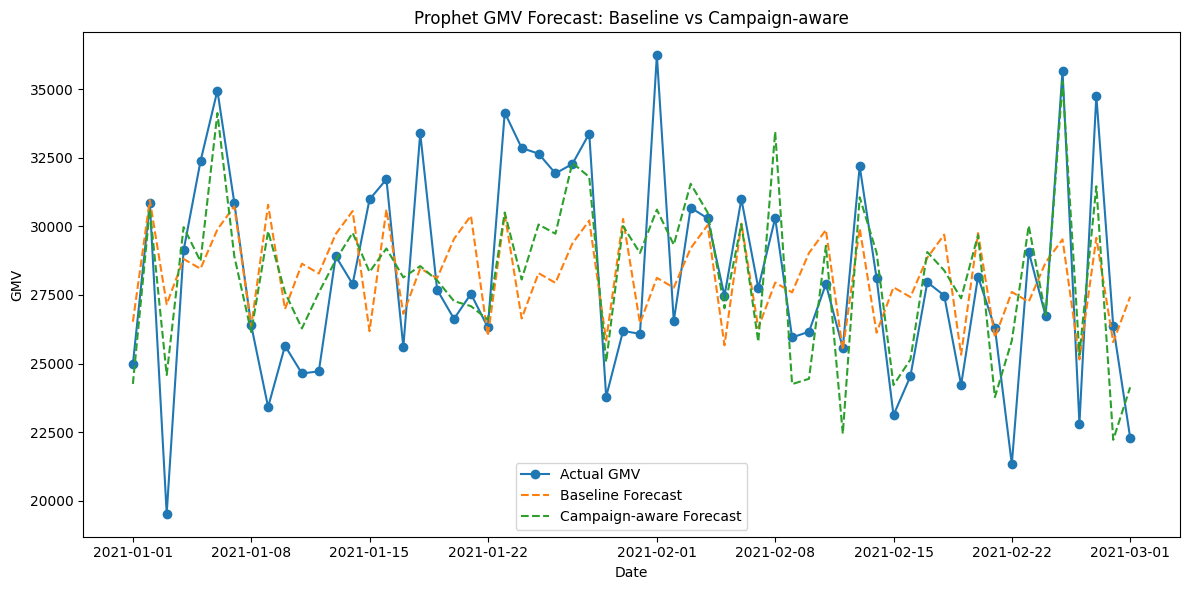

In [ ]:
# =========================================================
# 4. Run Main
# =========================================================
def main():
    daily = load_and_prepare("enhanced_synthetic_discount_dataset.csv")
    merged, metrics_base, metrics_camp, avg_uplift = run_comparison(daily)
    return merged, metrics_base, metrics_camp, avg_uplift

if __name__ == "__main__":
    merged, metrics_base, metrics_camp, avg_uplift = main()